# Lite Agent — how is it doing?

Diagnostics for a PPO agent trained on the **lite** game (`railroad_lite_env`): plains only,
no disruption, 25 turns, half-idle random opponent, 16 observation channels, PLACE-only actions.

Four things to look at, in the order they're usually worth checking:

1. **Training curves** — is score/win-rate still climbing, and are the PPO health metrics sane?
2. **Evaluation** — how does it actually do over many games, versus a random baseline?
3. **The board** — does it build *corridors between towns*, or just scatter track?
4. **Turn by turn** — what the network sees and picks on each individual decision.

Run "Setup" once, then any section below it.

## Setup

In [1]:
%matplotlib inline
import glob
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "docs" else Path.cwd()))

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from railroad_lite_env import LITE_CHANNEL_NAMES, NUM_LITE_CHANNELS, RailroadLiteEnv
from training.lite import LiteGameSimulator, lite_encode_state
from training.lite_model import LiteUNet

# Defaults to the newest lite checkpoint on disk; set a path explicitly to pin one.
CHECKPOINT_PATH = max(glob.glob("checkpoints/*lite*.pt"), key=lambda p: Path(p).stat().st_mtime, default=None)
EPSILON = 0.0          # 0 = greedy/deployment behaviour, which is how you'd actually run it
GRID_HEIGHT = None     # None = authentic random size (h 14..20)
SEED = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

if CHECKPOINT_PATH is not None:
    blob = torch.load(CHECKPOINT_PATH, map_location=device)
    model = LiteUNet(**blob.get("model_kwargs", {})).to(device)
    model.load_state_dict(blob["model_state_dict"])
    print(f"Loaded {CHECKPOINT_PATH}  (iteration {blob.get('iteration', '?')})")
else:
    model = LiteUNet().to(device)
    print("No lite checkpoint found - using a random-init model")
model.eval()
print(f"{sum(p.numel() for p in model.parameters()):,} parameters on {device}")


Loaded checkpoints/20260909-184444-lite_iter1600.pt  (iteration 1600)
548,962 parameters on cuda


## Helpers

In [2]:
def greedy_action(model, sim, epsilon=0.0, rng=None):
    """One forward pass -> (action, policy probabilities, value estimate, chosen canvas cell)."""
    state, mask = sim.get_encoded_state(), sim.get_action_mask()
    with torch.no_grad():
        x = torch.from_numpy(state).unsqueeze(0).to(device)
        m = torch.from_numpy(mask).unsqueeze(0).to(device)
        logits, value = model(x, m)
        flat = logits.flatten(1)
        probs = torch.softmax(flat, dim=1).view_as(logits)[0, 0].cpu().numpy()
        if rng is not None and rng.random_sample() < epsilon:
            index = int(torch.distributions.Categorical(logits=flat).sample().item())
        else:
            index = int(torch.argmax(flat, dim=1).item())
    row, col = divmod(index, mask.shape[2])
    pad_top, pad_left = sim.pad_offsets
    return ("PLACE", col - pad_left, row - pad_top), probs, float(value.item()), (row, col)


def play_game(model, seed, epsilon=0.0):
    """Play one full lite game and return the finished simulator."""
    rng = np.random.RandomState(seed)
    env = RailroadLiteEnv(grid_height=GRID_HEIGHT, seed=seed)
    env.reset()
    sim = LiteGameSimulator.from_env(env)
    while not sim.is_game_over():
        action, _, _, _ = greedy_action(model, sim, epsilon, rng)
        sim.apply(action)
    return sim


def play_random_game(seed):
    """Same game, but player 0 places uniformly at random - the baseline to beat."""
    rng = np.random.RandomState(seed)
    env = RailroadLiteEnv(grid_height=GRID_HEIGHT, seed=seed)
    env.reset()
    sim = LiteGameSimulator.from_env(env)
    while not sim.is_game_over():
        legal = sim.get_legal_actions()
        sim.apply(legal[rng.randint(len(legal))])
    return sim


def game_stats(sim):
    gs = sim.game_state
    wanted = sum(len(t.desired_connections) for t in gs.towns)
    made = sum(len(t.paths) for t in gs.towns)
    return {
        "score": gs.scores[0],
        "opponent": gs.scores[1],
        "margin": gs.scores[0] - gs.scores[1],
        "won": gs.scores[0] > gs.scores[1],
        "connections": made,
        "wanted": wanted,
    }


## 1. Training curves

Reads the TensorBoard scalars straight off disk. `player0_score` and `win_rate` are what you
actually care about; the rest are PPO health checks - `approx_kl` should stay small (roughly
< 0.1), and `entropy` collapsing to 0 would mean the policy has stopped exploring entirely.

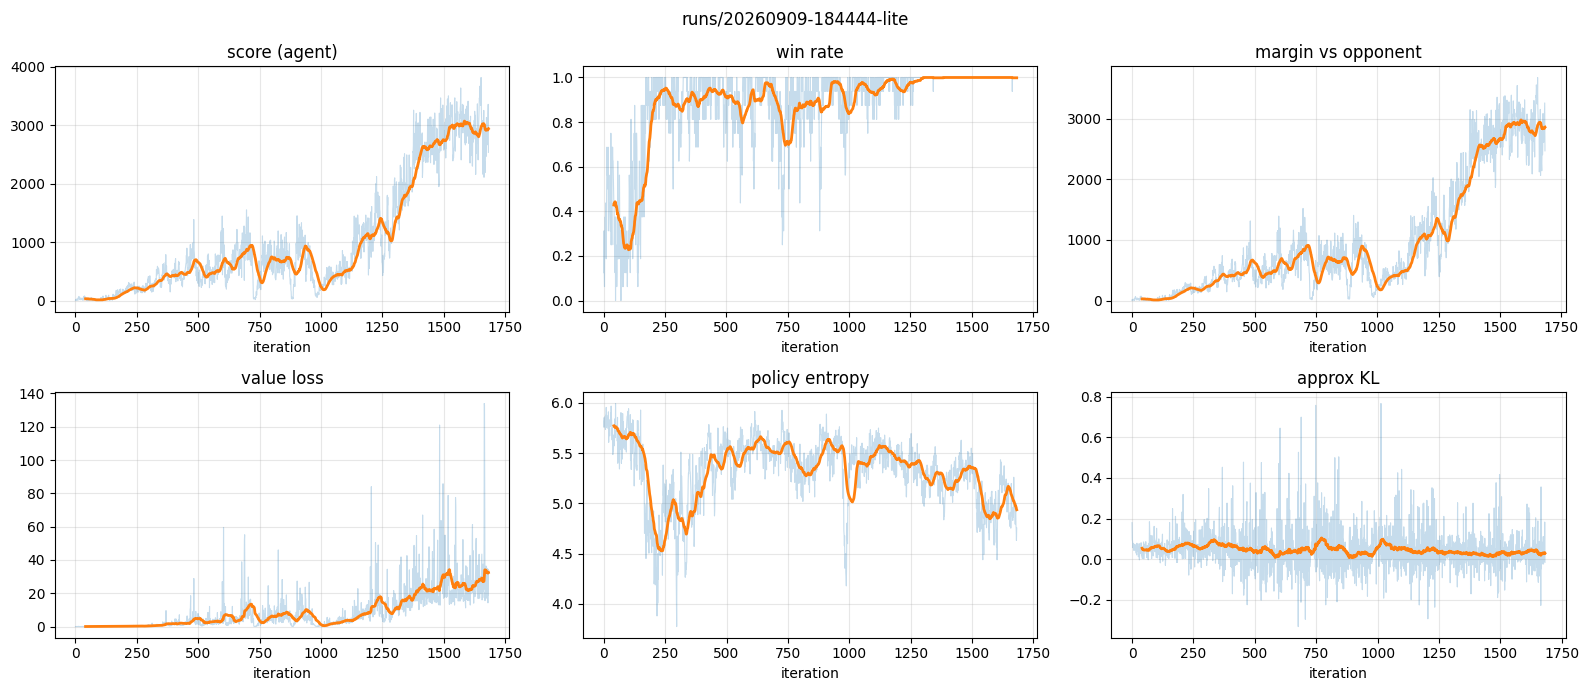

last-10-iteration averages:
  self_play/player0_score        2879.306
  self_play/win_rate                1.000
  self_play/score_margin         2810.206
  train/value_loss                 25.364
  train/entropy                     4.842
  train/approx_kl                   0.042


In [3]:
from tensorboard.backend.event_processing import event_accumulator

RUN_DIR = max(glob.glob("runs/*lite*"), key=lambda p: Path(p).stat().st_mtime, default=None)

if RUN_DIR is None:
    print("No lite run directory found under runs/")
else:
    ea = event_accumulator.EventAccumulator(RUN_DIR, size_guidance={"scalars": 0})
    ea.Reload()
    available = set(ea.Tags()["scalars"])
    panels = [
        ("self_play/player0_score", "score (agent)"),
        ("self_play/win_rate", "win rate"),
        ("self_play/score_margin", "margin vs opponent"),
        ("train/value_loss", "value loss"),
        ("train/entropy", "policy entropy"),
        ("train/approx_kl", "approx KL"),
    ]
    panels = [(t, lbl) for t, lbl in panels if t in available]

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    for ax, (tag, label) in zip(axes.flat, panels):
        events = ea.Scalars(tag)
        steps = [e.step for e in events]
        vals = np.array([e.value for e in events])
        ax.plot(steps, vals, alpha=0.25, lw=0.8)
        if len(vals) >= 20:  # smoothed trend on top of the raw per-iteration noise
            w = max(5, len(vals) // 40)
            ax.plot(steps[w - 1:], np.convolve(vals, np.ones(w) / w, mode="valid"), lw=2)
        ax.set_title(label)
        ax.set_xlabel("iteration")
        ax.grid(alpha=0.3)
    for ax in axes.flat[len(panels):]:
        ax.axis("off")
    fig.suptitle(f"{RUN_DIR}", fontsize=12)
    plt.tight_layout()
    plt.show()

    last = {t: np.mean([e.value for e in ea.Scalars(t)][-10:]) for t, _ in panels}
    print("last-10-iteration averages:")
    for tag, value in last.items():
        print(f"  {tag:28s} {value:10.3f}")


## 2. Evaluation

Plays `N_GAMES` complete games greedily (`EPSILON = 0`) on fresh random maps, and the *same*
maps with a random player, so the comparison controls for map difficulty.

agent            score  3474.6 +-  975.2   margin +3397.7   win rate 1.00   connections 336/450 (75%)   scored 0 in 0/20 games
random baseline  score     0.6 +-    2.6   margin    +0.0   win rate 0.00   connections 1/450 (0%)   scored 0 in 19/20 games


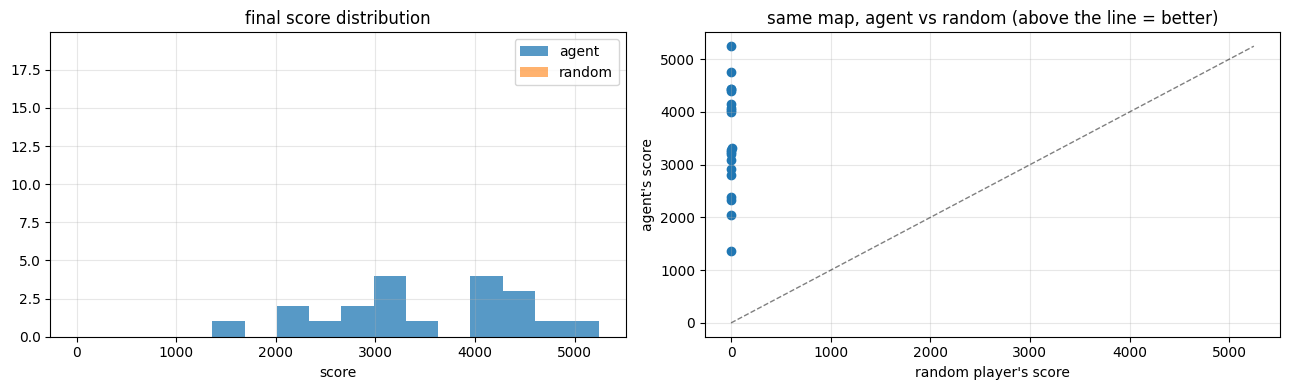

In [4]:
N_GAMES = 20

agent = [game_stats(play_game(model, seed=1000 + i, epsilon=EPSILON)) for i in range(N_GAMES)]
random_baseline = [game_stats(play_random_game(seed=1000 + i)) for i in range(N_GAMES)]

def summarize(name, rows):
    score = np.array([r["score"] for r in rows])
    margin = np.array([r["margin"] for r in rows])
    made = np.array([r["connections"] for r in rows])
    wanted = np.array([r["wanted"] for r in rows])
    print(f"{name:16s} score {score.mean():7.1f} +- {score.std():6.1f}   "
          f"margin {margin.mean():+7.1f}   win rate {np.mean([r['won'] for r in rows]):.2f}   "
          f"connections {made.sum()}/{wanted.sum()} ({made.sum() / max(1, wanted.sum()):.0%})   "
          f"scored 0 in {(score == 0).sum()}/{len(rows)} games")

summarize("agent", agent)
summarize("random baseline", random_baseline)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist([r["score"] for r in agent], bins=12, alpha=0.75, label="agent")
axes[0].hist([r["score"] for r in random_baseline], bins=12, alpha=0.6, label="random")
axes[0].set_title("final score distribution"); axes[0].set_xlabel("score"); axes[0].legend()

pairs = np.array([[a["score"], b["score"]] for a, b in zip(agent, random_baseline)])
axes[1].scatter(pairs[:, 1], pairs[:, 0])
lim = max(1, pairs.max())
axes[1].plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("random player's score"); axes[1].set_ylabel("agent's score")
axes[1].set_title("same map, agent vs random (above the line = better)")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Performance by map size

The map is a different size every game (height 14-20), and bigger maps carry more towns, each
wanting more connections. Splitting the evaluation by size shows whether the agent handles that
range evenly or only does well on part of it - if score falls off sharply with size, the fixed
75-track budget (25 turns x 3) is being spread too thin across too many objectives rather than
committed to finishing a few.

     map  towns  games  mean score  connections
   21x14      5      2        2209    19/19     (100%)
   23x15      6      3        3071    38/38     (100%)
   24x16      7      2        3595    32/32     (100%)
   26x17      8      6        3932   113/117    (97%)
   27x18      9      3        4131    67/76     (88%)
   29x19     11      2        3240    32/79     (41%)
   30x20     12      2        3102    35/89     (39%)


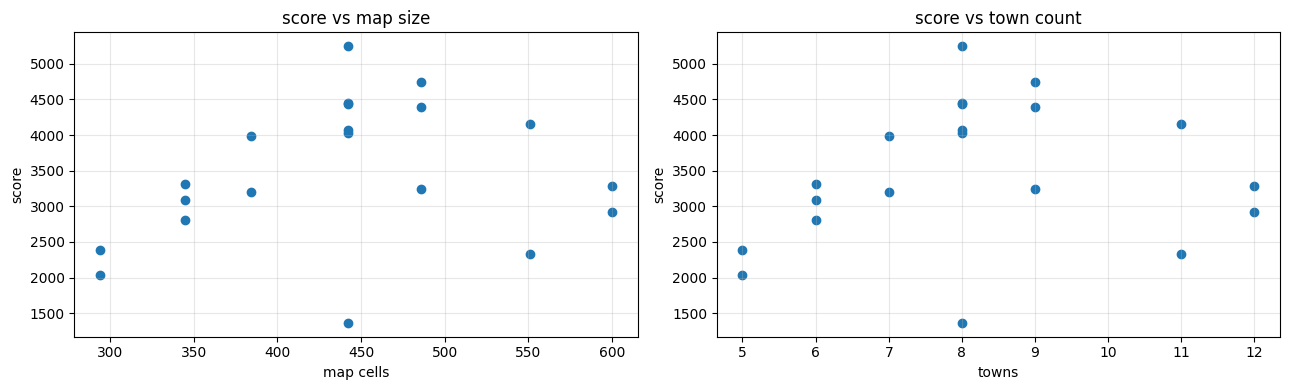

In [5]:
rows = []
for i in range(N_GAMES):
    sim = play_game(model, seed=1000 + i, epsilon=EPSILON)
    gs = sim.game_state
    closest = min((abs(t.coord[0] - o.coord[0]) + abs(t.coord[1] - o.coord[1])
                   for t in gs.towns for o in t.desired_connections), default=np.nan)
    rows.append({"cells": gs.width * gs.height, "size": f"{gs.width}x{gs.height}",
                 "towns": len(gs.towns), "score": gs.scores[0],
                 "connections": sum(len(t.paths) for t in gs.towns),
                 "wanted": sum(len(t.desired_connections) for t in gs.towns),
                 "closest_pair": closest})

by_size = {}
for r in rows:
    by_size.setdefault(r["size"], []).append(r)

print(f"{'map':>8} {'towns':>6} {'games':>6} {'mean score':>11} {'connections':>12}")
for size in sorted(by_size, key=lambda s: by_size[s][0]["cells"]):
    g = by_size[size]
    made, wanted = sum(r["connections"] for r in g), sum(r["wanted"] for r in g)
    print(f"{size:>8} {g[0]['towns']:>6} {len(g):>6} {np.mean([r['score'] for r in g]):>11.0f} "
          f"{made:>5}/{wanted:<6} ({made / max(1, wanted):.0%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter([r["cells"] for r in rows], [r["score"] for r in rows])
axes[0].set_xlabel("map cells"); axes[0].set_ylabel("score"); axes[0].set_title("score vs map size")
axes[1].scatter([r["towns"] for r in rows], [r["score"] for r in rows])
axes[1].set_xlabel("towns"); axes[1].set_ylabel("score"); axes[1].set_title("score vs town count")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

zeros = [r for r in rows if r["score"] == 0]
if zeros:
    print(f"\n{len(zeros)}/{len(rows)} games scored nothing. Their closest desired pair was "
          f"{np.nanmean([r['closest_pair'] for r in zeros]):.1f} cells apart on average - well "
          f"inside the 75-track budget, so these are not unwinnable maps.")


## 3. What the board actually looks like

The single most informative check: does the agent lay **corridors between towns**, or spray
track around? Cells on an active connection are outlined — those are the ones actually paying
out every turn.

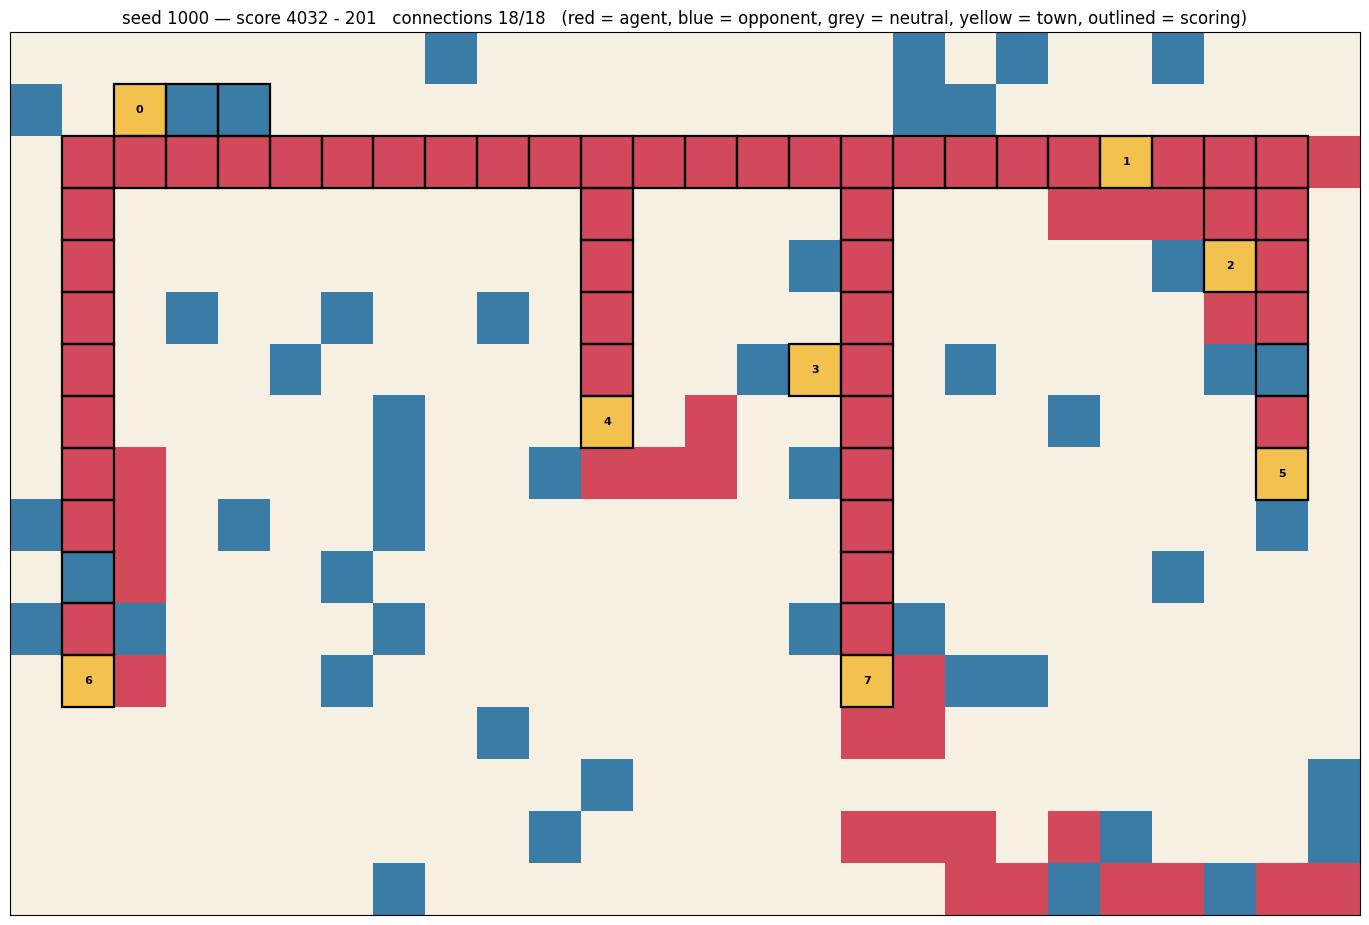

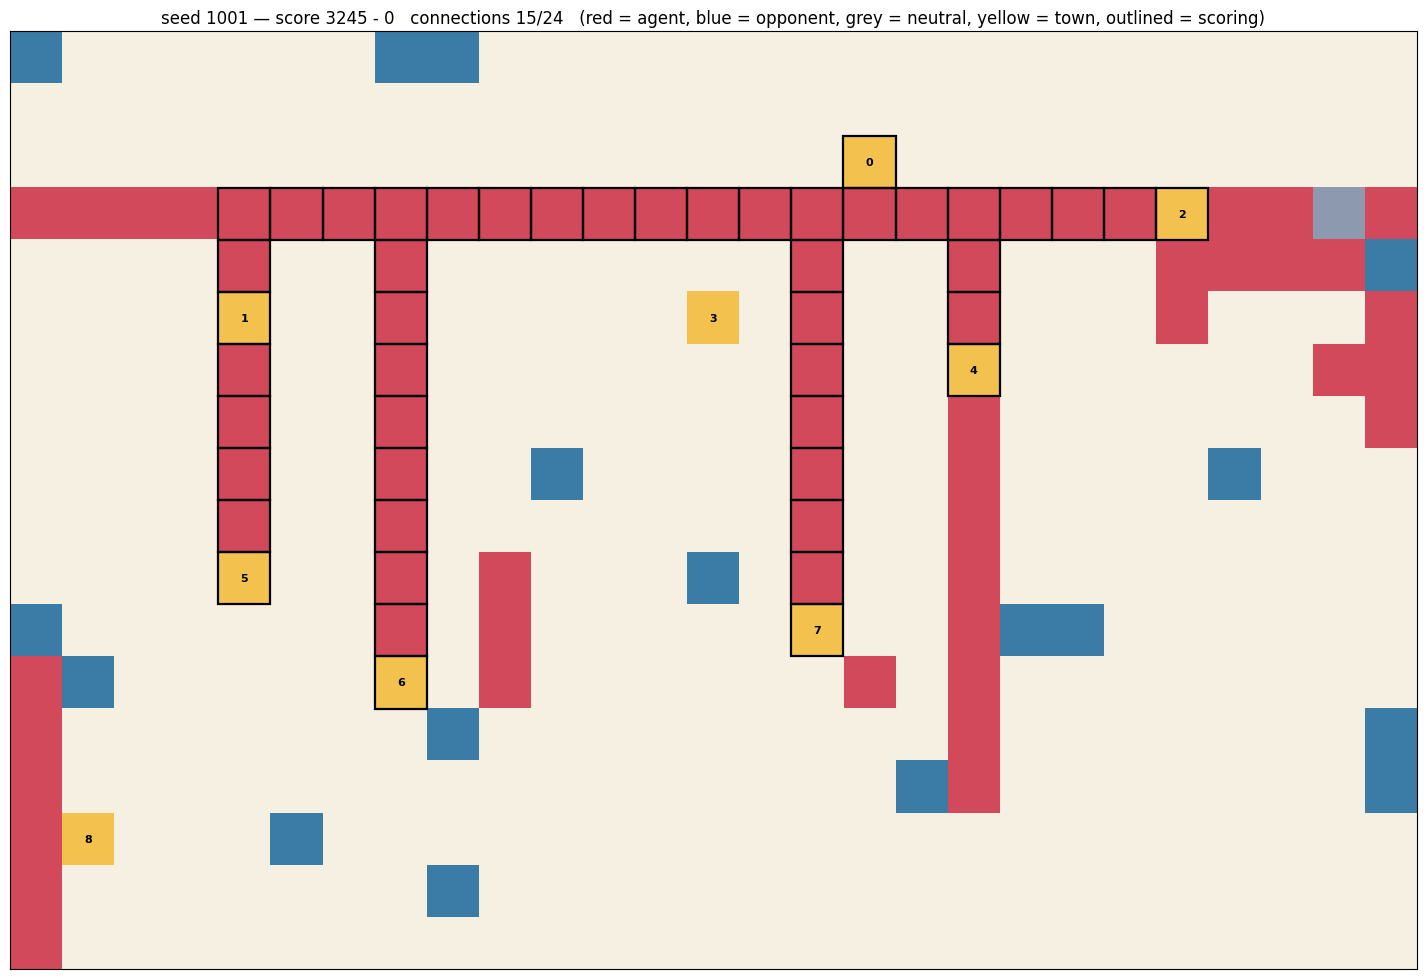

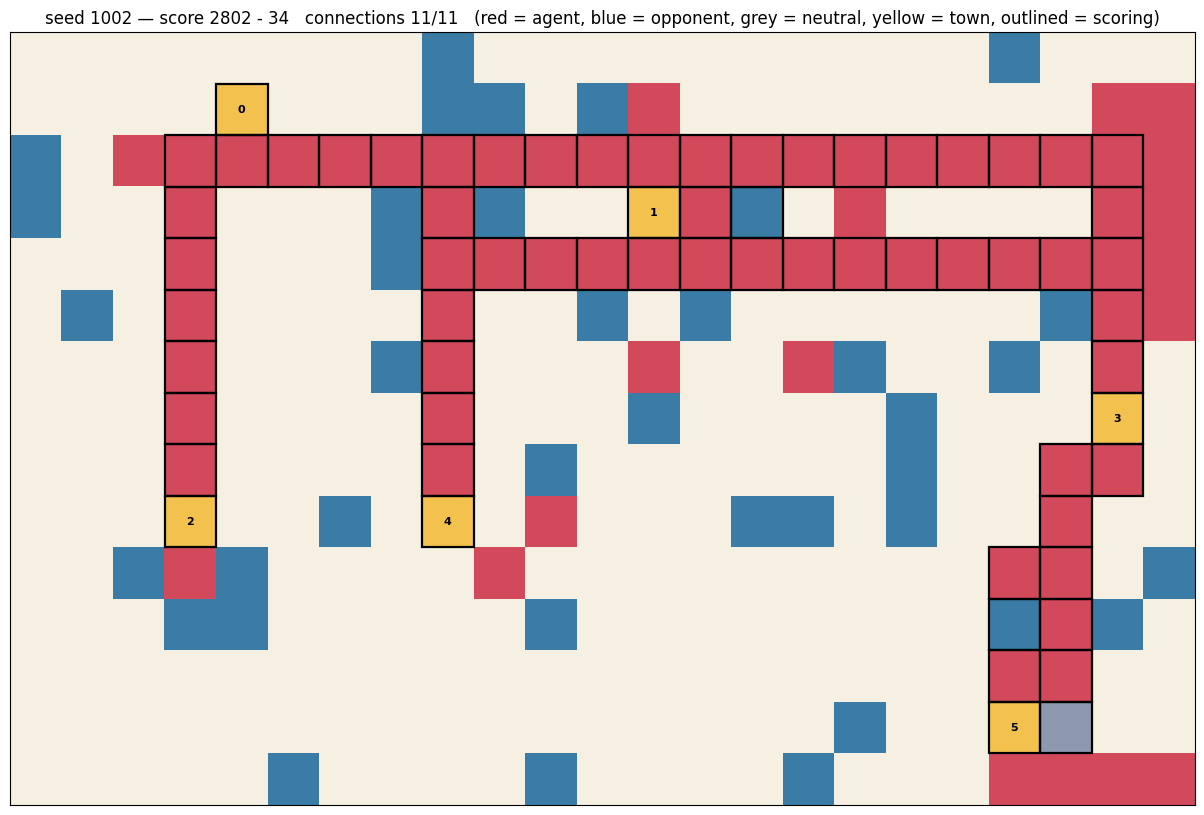

In [6]:
def plot_board(sim, title=""):
    gs = sim.game_state
    board = np.zeros((gs.height, gs.width))
    board[gs.tracks == 0] = 1   # agent
    board[gs.tracks == 1] = 2   # opponent
    board[gs.tracks == 2] = 3   # neutral
    for t in gs.towns:
        board[t.coord[1], t.coord[0]] = 4

    cmap = ListedColormap(["#f5f0e1", "#d1495b", "#3a7ca5", "#8d99ae", "#f2c14e"])
    fig, ax = plt.subplots(figsize=(min(16, gs.width * 0.55), min(11, gs.height * 0.55)))
    ax.imshow(board, cmap=cmap, vmin=0, vmax=4)

    active = sim.game_state.calculate_active_connections()
    for (x, y) in active:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, edgecolor="black", lw=1.6))
    for t in gs.towns:
        ax.text(t.coord[0], t.coord[1], str(t.id), ha="center", va="center", fontsize=8, weight="bold")

    made = sum(len(t.paths) for t in gs.towns)
    wanted = sum(len(t.desired_connections) for t in gs.towns)
    ax.set_title(
        f"{title}score {gs.scores[0]} - {gs.scores[1]}   "
        f"connections {made}/{wanted}   (red = agent, blue = opponent, grey = neutral, "
        f"yellow = town, outlined = scoring)"
    )
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()


for seed in (1000, 1001, 1002):
    plot_board(play_game(model, seed=seed, epsilon=EPSILON), title=f"seed {seed} — ")


## 4. Turn by turn

Re-run the cell below repeatedly — each run advances one turn (3 placements at 1 paint point
each) and plots the policy heatmap for every individual decision, so you can see how each pick
reacts to the one before it.

In [7]:
# (Re-)start a game to step through.
step_env = RailroadLiteEnv(grid_height=GRID_HEIGHT, seed=SEED)
step_env.reset()
step_sim = LiteGameSimulator.from_env(step_env)
step_rng = np.random.RandomState(SEED)

gs = step_sim.game_state
print(f"Map {gs.width}x{gs.height}, {len(gs.towns)} towns, {gs.max_turns} turns")
print(f"{'id':>3}  {'(x, y)':>8}  wants")
for t in gs.towns:
    print(f"{t.id:>3}  ({t.coord[0]:>2}, {t.coord[1]:>2})  -> "
          f"{', '.join(str(o.id) for o in t.desired_connections) or '(none)'}")


Map 27x18, 9 towns, 25 turns
 id    (x, y)  wants
  0  (12,  2)  -> 5, 6, 8
  1  ( 3,  3)  -> 0
  2  (15,  4)  -> 1, 7, 8
  3  ( 9,  5)  -> 1, 2, 4
  4  (21,  6)  -> 0, 6, 7
  5  (16,  9)  -> 1, 4, 6
  6  ( 8, 11)  -> 1, 2
  7  (21, 10)  -> 3, 6, 8
  8  ( 5, 13)  -> 1, 3, 5


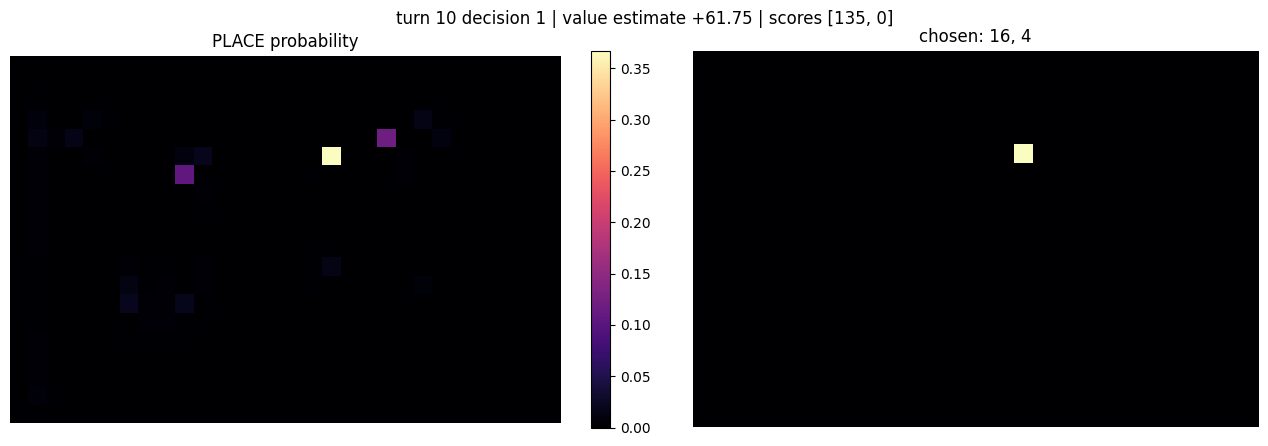

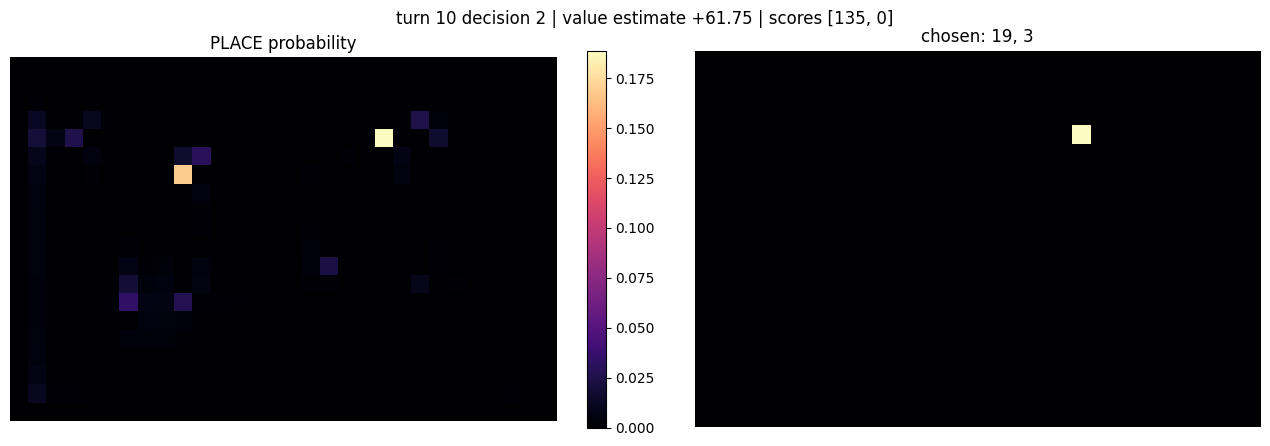

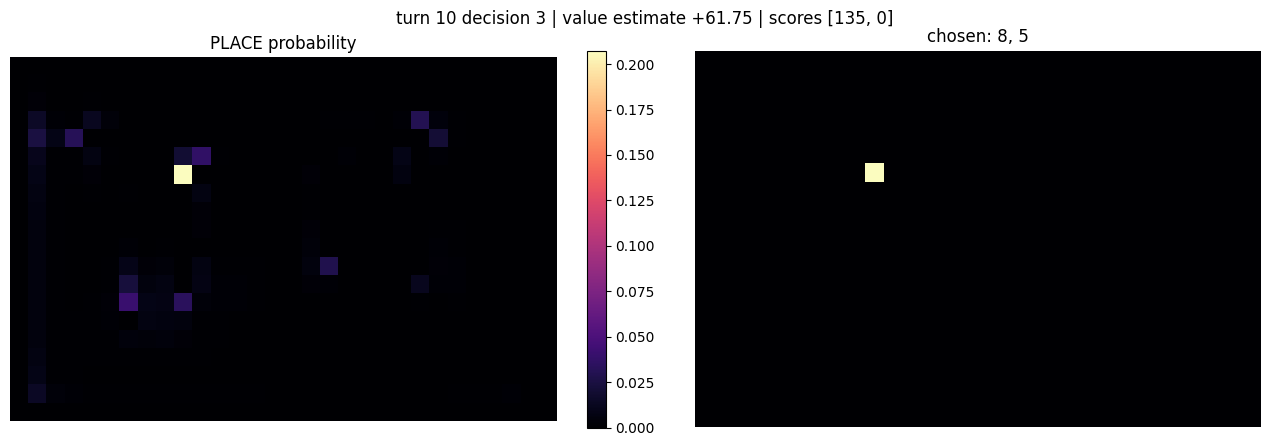

Turn 11/25 | score 224 - 0 | connections 8


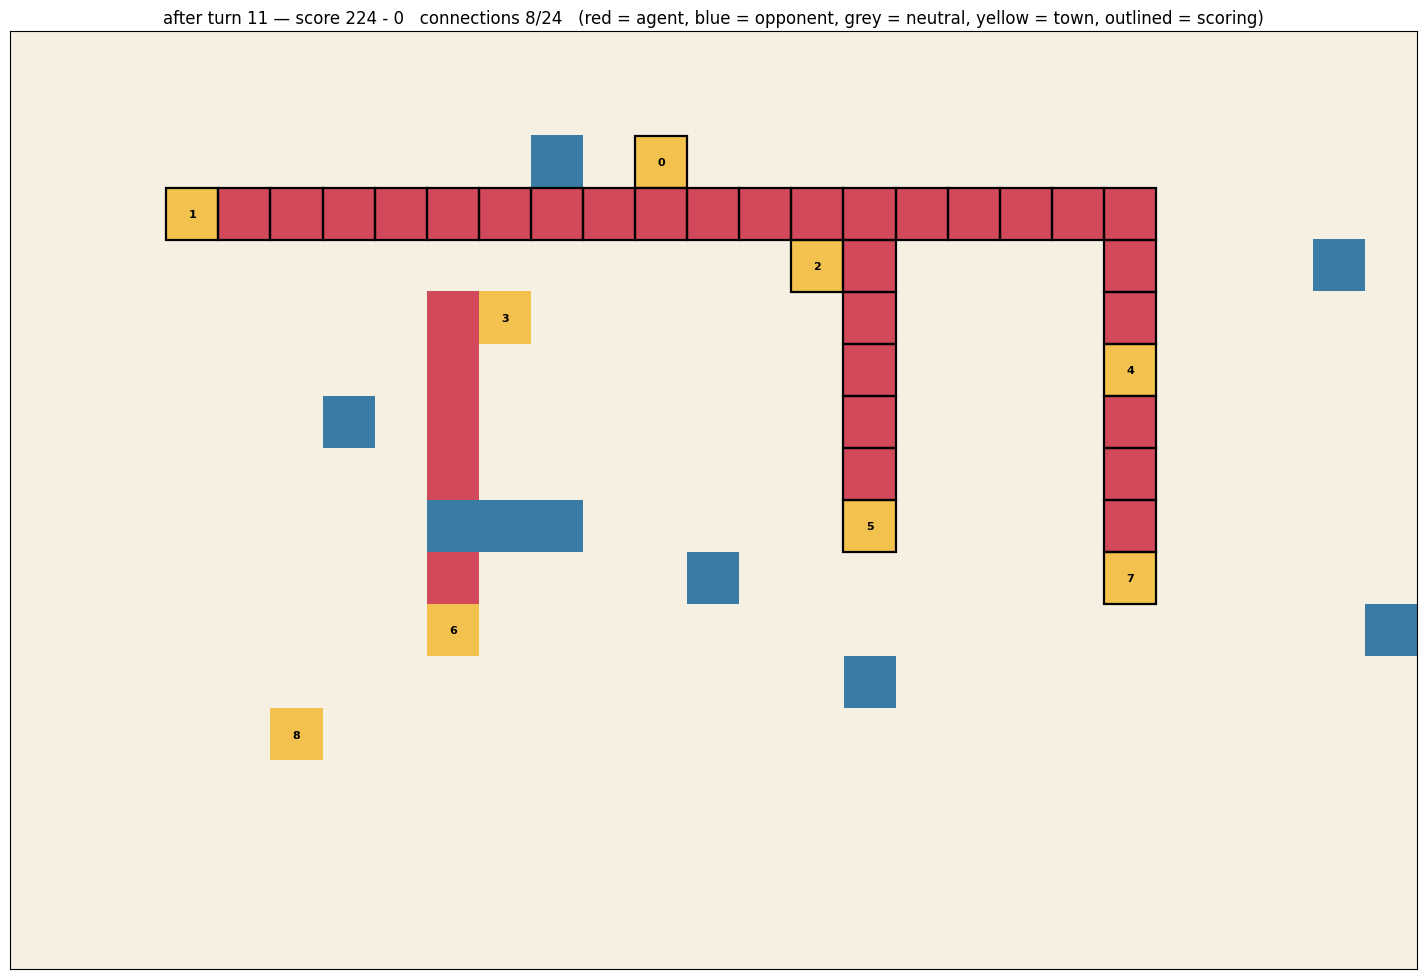

In [20]:
if step_sim.is_game_over():
    print(f"Game over. Final score: {step_sim.game_state.scores}. Re-run the cell above to restart.")
else:
    turn = step_sim.game_state.turn
    decision = 0
    while not step_sim.is_game_over() and step_sim.game_state.turn == turn:
        decision += 1
        action, probs, value, (row, col) = greedy_action(model, step_sim, EPSILON, step_rng)

        chosen = np.zeros_like(probs)
        chosen[row, col] = 1.0
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        im = axes[0].imshow(probs, cmap="magma", vmin=0)
        axes[0].set_title("PLACE probability"); axes[0].axis("off")
        fig.colorbar(im, ax=axes[0], fraction=0.046)
        axes[1].imshow(chosen, cmap="magma", vmin=0, vmax=1)
        axes[1].set_title(f"chosen: {action[1]}, {action[2]}"); axes[1].axis("off")
        fig.suptitle(f"turn {turn} decision {decision} | value estimate {value:+.2f} "
                     f"| scores {step_sim.game_state.scores}")
        plt.tight_layout(); plt.show()

        step_sim.apply(action)

    gs = step_sim.game_state
    print(f"Turn {gs.turn}/{gs.max_turns} | score {gs.scores[0]} - {gs.scores[1]} | "
          f"connections {sum(len(t.paths) for t in gs.towns)}")
    plot_board(step_sim, title=f"after turn {gs.turn} — ")


## 5. All 16 input channels

What the network actually receives for the current position of the stepping game above — the
20x30 canvas, with the real board centered and the padding marked as off-board.

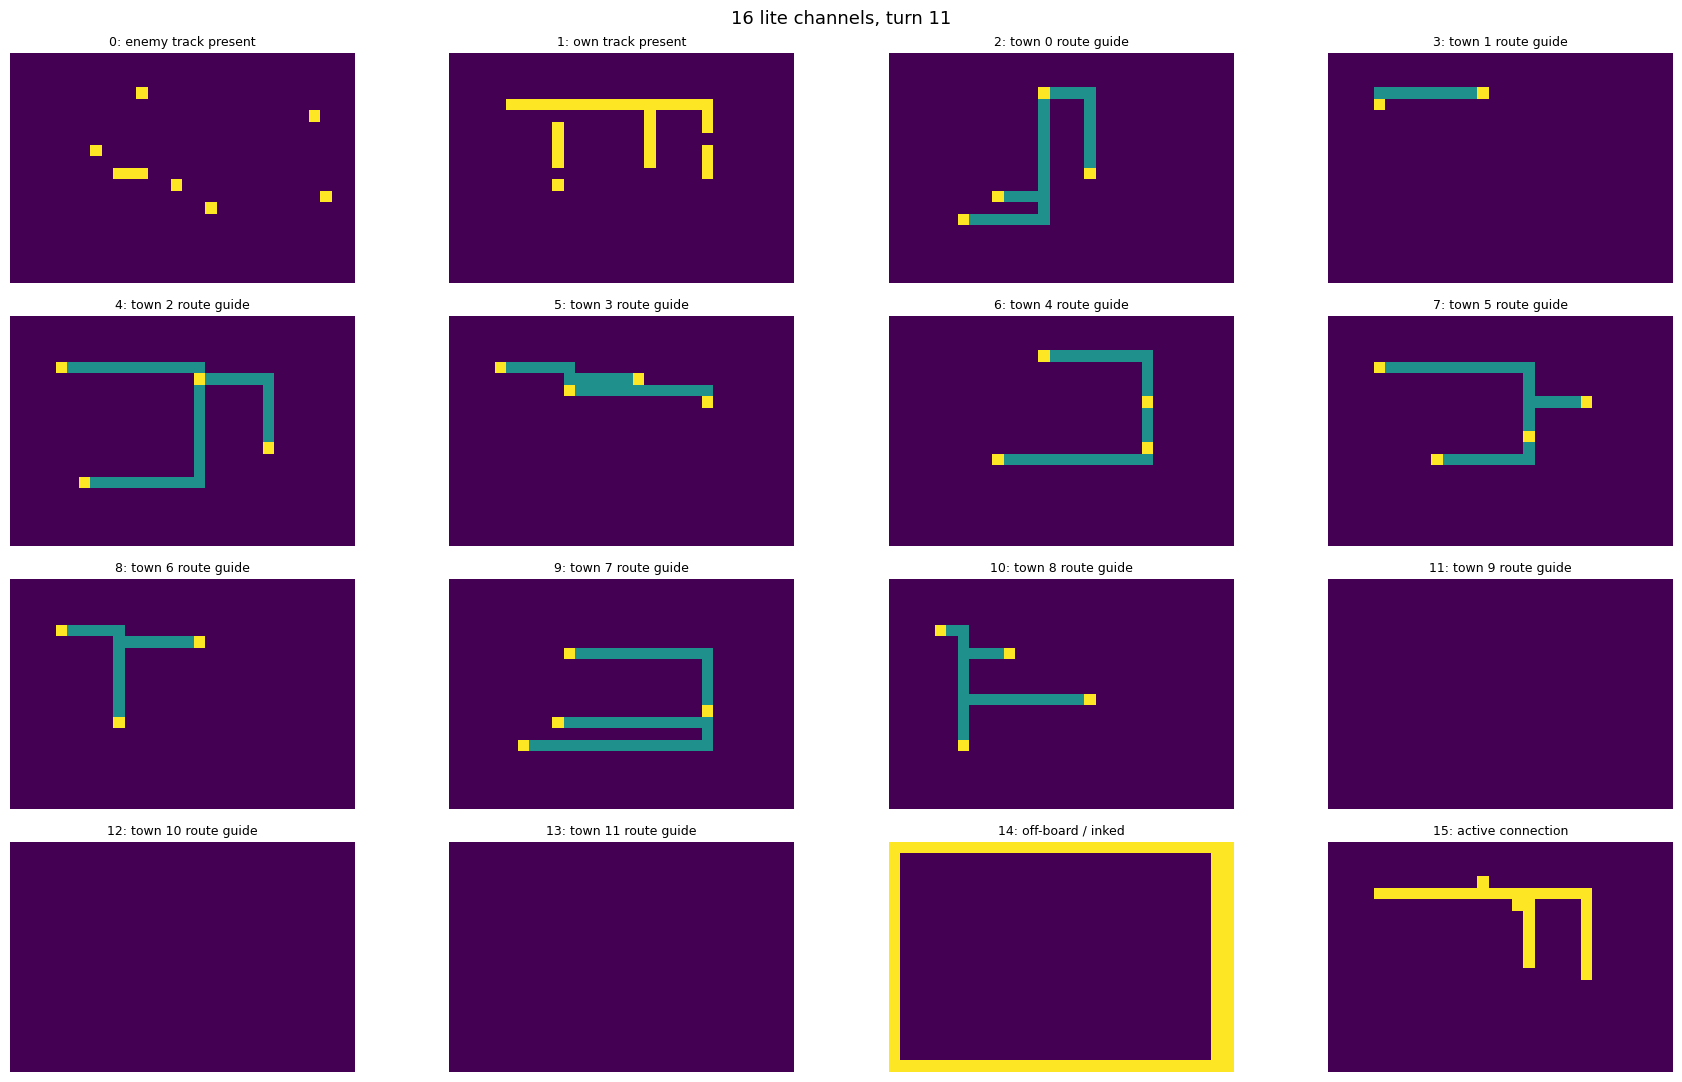

In [21]:
state = step_sim.get_encoded_state()
fig, axes = plt.subplots(4, 4, figsize=(18, 11))
for i, ax in enumerate(axes.flat):
    ax.imshow(state[i], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{i}: {LITE_CHANNEL_NAMES[i]}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"{NUM_LITE_CHANNELS} lite channels, turn {step_sim.game_state.turn}", fontsize=13)
plt.tight_layout(); plt.show()
